## What is regularisation?

Regularization is a method used to stop a machine learning model from becoming too complicated and overfitting the training data.

#### L1 regularisation (Lasso regresion)

Adds the absolute value of coefficients as penalty.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler  
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

from sklearn.linear_model import Lasso

In [12]:
housing = fetch_california_housing()
x = pd.DataFrame(housing.data,columns=housing.feature_names)

In [13]:
y = housing.target

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler() #performing standardisation on the data

In [16]:
x_train = scaler.fit_transform(x_train)

In [17]:
x_test = scaler.transform(x_test)

In [18]:
lasso = Lasso(alpha=0.1)

In [19]:
lasso.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [20]:
y_pred = lasso.predict(x_test)

In [24]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.8244
R² Score: 0.4814


In [27]:
coefficients = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': lasso.coef_
})
coefficients

,Feature,Coefficient
0,MedInc,0.710598
1,HouseAge,0.106453
2,AveRooms,-0.000000
3,AveBedrms,0.000000
4,Population,-0.000000
5,AveOccup,-0.000000
6,Latitude,-0.011469
7,Longitude,-0.000000


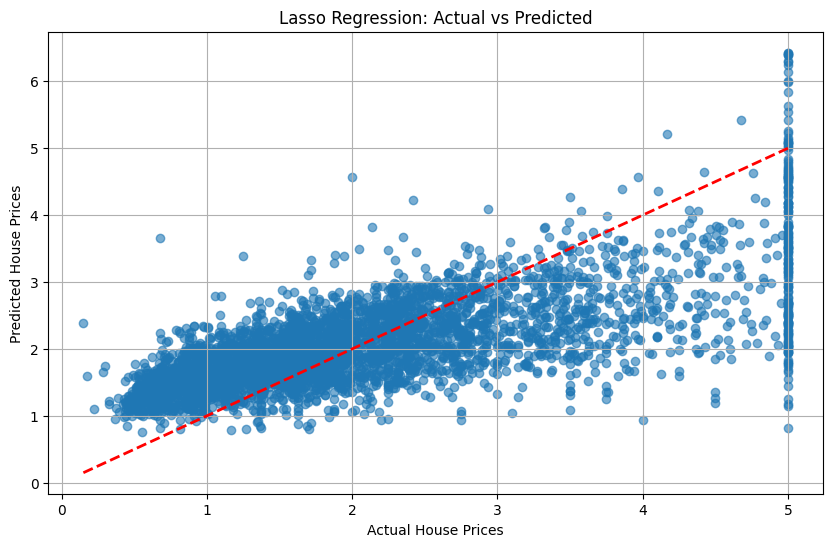

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Lasso Regression: Actual vs Predicted")

plt.grid(True)

plt.show()

#l2 regularisation

In [29]:
# =========================================================
# LOAN PREDICTION USING MULTIPLE CLASSIFICATION ALGORITHMS
# =========================================================

# =========================
# IMPORT LIBRARIES
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Train Test Split
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("loanfile.csv")

print(df.head())

# =========================
# DATA INFORMATION
# =========================

print(df.info())

print("\nShape of Dataset:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# =========================
# HANDLE MISSING VALUES
# =========================

# Fill LoanAmount with mean
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())

# Fill Credit_History with median
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

# Drop remaining null values
df.dropna(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# =========================
# DATA VISUALIZATION
# =========================

plt.figure(figsize=(18,10))

# Gender
plt.subplot(231)
sns.countplot(x='Gender', hue='Loan_Status', data=df)

# Married
plt.subplot(232)
sns.countplot(x='Married', hue='Loan_Status', data=df)

# Education
plt.subplot(233)
sns.countplot(x='Education', hue='Loan_Status', data=df)

# Self Employed
plt.subplot(234)
sns.countplot(x='Self_Employed', hue='Loan_Status', data=df)

# Property Area
plt.subplot(235)
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)

plt.tight_layout()
plt.show()

# =========================
# LABEL ENCODING
# =========================

# Target Variable
df['Loan_Status'] = df['Loan_Status'].replace({'Y':1, 'N':0})

# Gender
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

# Married
df['Married'] = df['Married'].map({'Yes':1, 'No':0})

# Education
df['Education'] = df['Education'].map({'Graduate':1, 'Not Graduate':0})

# Self Employed
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1, 'No':0})

# Property Area
df['Property_Area'] = df['Property_Area'].map({
    'Rural':0,
    'Semiurban':1,
    'Urban':2
})

# Dependents
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

# =========================
# DROP LOAN_ID
# =========================

df.drop('Loan_ID', axis=1, inplace=True)

# =========================
# FEATURE & TARGET SELECTION
# =========================

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0
)

# =========================================================
# FUNCTION TO EVALUATE MODELS
# =========================================================

def evaluate_model(model, model_name):

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Print Results
    print("\n====================================")
    print(f"{model_name}")
    print("====================================")

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # Heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# =========================================================
# 1. LOGISTIC REGRESSION
# =========================================================

lr_model = LogisticRegression(max_iter=1000)

evaluate_model(lr_model, "Logistic Regression")

# =========================================================
# 2. K-NEAREST NEIGHBORS (KNN)
# =========================================================

knn_model = KNeighborsClassifier(n_neighbors=5)

evaluate_model(knn_model, "K-Nearest Neighbors")

# =========================================================
# 3. DECISION TREE
# =========================================================

dt_model = DecisionTreeClassifier(random_state=0)

evaluate_model(dt_model, "Decision Tree")

# =========================================================
# 4. RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)

evaluate_model(rf_model, "Random Forest")

# =========================================================
# 5. SUPPORT VECTOR MACHINE (SVM)
# =========================================================

svm_model = SVC()

evaluate_model(svm_model, "Support Vector Machine")

# =========================================================
# 6. NAIVE BAYES
# =========================================================

nb_model = GaussianNB()

evaluate_model(nb_model, "Naive Bayes")

FileNotFoundError: [Errno 2] No such file or directory: 'loanfile.csv'